# Advanced Analytics

This notebook performs Day 6 advanced analytics with output graphs for VaR/CVaR, rolling Sharpe, investor cohorts, SIP continuity, and sector HHI.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'data' / 'processed').exists():
    BASE_DIR = BASE_DIR.parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

fund_master = pd.read_csv(PROCESSED_DIR / '01_fund_master.csv', parse_dates=['launch_date'])
scheme_perf = pd.read_csv(PROCESSED_DIR / '07_scheme_performance.csv')
nav_history = pd.read_csv(PROCESSED_DIR / '02_nav_history.csv', parse_dates=['date'])
transactions = pd.read_csv(PROCESSED_DIR / '08_investor_transactions.csv', parse_dates=['transaction_date'])
holdings = pd.read_csv(PROCESSED_DIR / '09_portfolio_holdings.csv', parse_dates=['portfolio_date'])

nav_history = nav_history.sort_values(['amfi_code', 'date']).copy()
nav_history['daily_return'] = nav_history.groupby('amfi_code')['nav'].pct_change()
nav_history.head()


,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210


## 1. Historical VaR and CVaR for All Funds
Compute 95% historical VaR and CVaR for each scheme.

In [2]:
def compute_var_cvar(returns: pd.Series) -> tuple[float, float]:
    values = returns.dropna().to_numpy(dtype=float)
    if values.size == 0:
        return np.nan, np.nan
    var = np.percentile(values, 5)
    cvar = values[values <= var].mean() if values[values <= var].size else np.nan
    return var * 100, cvar * 100

rows = []
for code, group in nav_history.groupby("amfi_code", sort=False):
    var, cvar = compute_var_cvar(group["daily_return"])
    rows.append({
        "amfi_code": int(code),
        "scheme_name": fund_master.loc[fund_master["amfi_code"] == code, "scheme_name"].iloc[0] if code in fund_master["amfi_code"].values else None,
        "var_95_pct": var,
        "cvar_95_pct": cvar,
    })
var_cvar_df = pd.DataFrame(rows).sort_values("var_95_pct").reset_index(drop=True)
var_cvar_df.to_csv(BASE_DIR / "var_cvar_report.csv", index=False)
var_cvar_df.head(10)


,amfi_code,scheme_name,var_95_pct,cvar_95_pct
0,101207,ABSL Small Cap Fund - Regular - Growth,-2.391462,-3.028854
1,119095,Axis Small Cap Fund - Regular - Growth,-2.328360,-2.969004
2,119599,SBI Small Cap Fund - Direct Plan - Growth,-2.315543,-3.016286
3,118634,Nippon India Small Cap Fund - Regular - Growth,-2.280981,-2.993962
4,149324,DSP Small Cap Fund - Regular - Growth,-2.152030,-2.857253
5,119598,SBI Small Cap Fund - Regular Plan - Growth,-2.150192,-2.844427
6,119094,Axis Midcap Fund - Regular - Growth,-1.699654,-2.237453
7,120842,Kotak Emerging Equity Fund - Regular - Growth,-1.694994,-2.125069
8,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-1.690163,-2.184984
9,102886,UTI Mid Cap Fund - Regular - Growth,-1.685705,-2.177063


## 2. Rolling 90-Day Sharpe Ratio for Top 5 Funds by AUM
Plot the rolling Sharpe ratio for the top 5 funds by AUM.

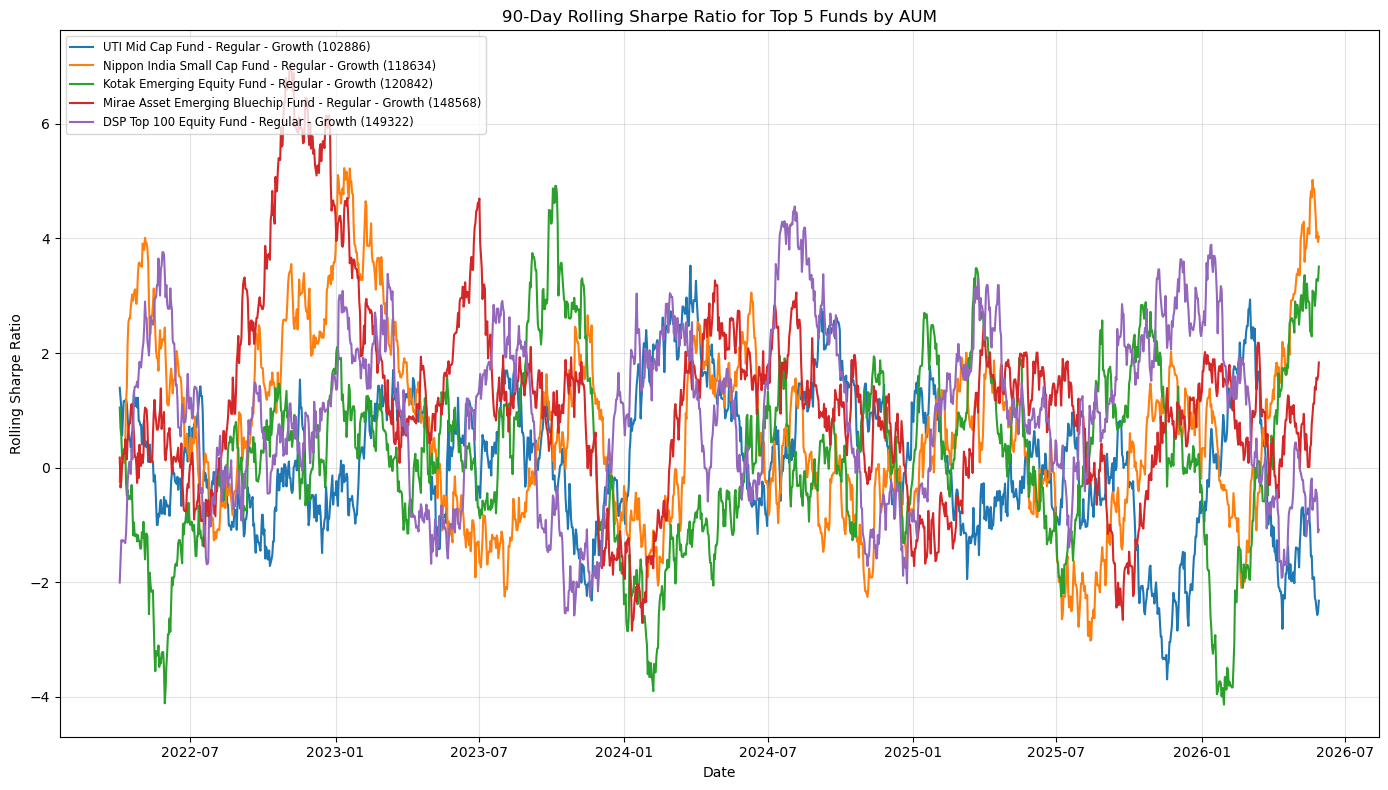

In [3]:
top_codes = scheme_perf.sort_values("aum_crore", ascending=False).head(5)["amfi_code"].tolist()
rolling = nav_history[nav_history["amfi_code"].isin(top_codes)].copy()
rolling["rolling_sharpe"] = rolling.groupby("amfi_code")["daily_return"].transform(lambda x: x.rolling(90, min_periods=90).mean() / x.rolling(90, min_periods=90).std() * np.sqrt(252))
rolling_plot = rolling.dropna(subset=["rolling_sharpe"]).copy()

plt.figure(figsize=(14, 8))
for code, group in rolling_plot.groupby("amfi_code", sort=False):
    name = fund_master.loc[fund_master["amfi_code"] == code, "scheme_name"].iloc[0] if code in fund_master["amfi_code"].values else str(code)
    plt.plot(group["date"], group["rolling_sharpe"], label=f"{name} ({code})")
plt.title("90-Day Rolling Sharpe Ratio for Top 5 Funds by AUM")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(loc="upper left", fontsize="small")
plt.grid(alpha=0.35)
plt.tight_layout()
plt.savefig(BASE_DIR / "rolling_sharpe_chart.png", dpi=200)
plt.show()


## 3. Investor Cohort Analysis
Analyze cohorts by the year of first investor transaction.

In [4]:
tx = transactions.copy()
tx["transaction_type"] = tx["transaction_type"].astype(str).str.upper()
tx["cohort_year"] = tx.groupby("investor_id")["transaction_date"].transform("min").dt.year
sip_only = tx[tx["transaction_type"] == "SIP"].copy()
cohort_sip = sip_only.groupby("cohort_year", as_index=False).agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_sip_amount=("amount_inr", "sum"),
    sip_tx_count=("transaction_id", "count"),
)
cohort_total = tx.groupby("cohort_year", as_index=False).agg(
    total_invested=("amount_inr", "sum"),
    investor_count=("investor_id", "nunique"),
)
top_fund = tx.groupby(["cohort_year", "amfi_code"], as_index=False).agg(total_amount=("amount_inr", "sum"))
top_fund = top_fund.sort_values(["cohort_year", "total_amount"], ascending=[True, False]).drop_duplicates("cohort_year")
top_fund = top_fund.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code", how="left")
top_fund = top_fund.rename(columns={"scheme_name": "top_fund_preference", "total_amount": "top_fund_invested"})
cohort_summary = cohort_total.merge(cohort_sip, on="cohort_year", how="left").merge(top_fund[["cohort_year", "top_fund_preference", "top_fund_invested"]], on="cohort_year", how="left")
cohort_summary.to_csv(BASE_DIR / "cohort_analysis.csv", index=False)
cohort_summary


,cohort_year,total_invested,investor_count,avg_sip_amount,total_sip_amount,sip_tx_count,top_fund_preference,top_fund_invested
0,2024,3491125187,4803,10996.885825,214978121,19549,UTI Nifty 50 Index Fund - Regular - Growth,100126141
1,2025,30455243,197,13505.209581,2255370,167,SBI Small Cap Fund - Direct Plan - Growth,1478507


## 4. SIP Continuity Analysis
Flag SIP investors with 6+ transactions and gaps over 35 days.

In [5]:
sip_tx = tx[tx["transaction_type"] == "SIP"].sort_values(["investor_id", "transaction_date"]).copy()
records = []
for investor_id, group in sip_tx.groupby("investor_id", sort=False):
    if len(group) < 6:
        continue
    diffs = group["transaction_date"].diff().dt.days.dropna()
    if diffs.empty:
        continue
    records.append({
        "investor_id": investor_id,
        "sip_transaction_count": len(group),
        "avg_gap_days": float(diffs.mean()),
        "max_gap_days": int(diffs.max()),
        "at_risk": diffs.max() > 35,
    })
continuity_df = pd.DataFrame(records)
continuity_df = continuity_df.sort_values(["at_risk", "max_gap_days"], ascending=[False, False]).reset_index(drop=True)
continuity_df.to_csv(BASE_DIR / "sip_continuity_report.csv", index=False)
continuity_df.head(10)


,investor_id,sip_transaction_count,avg_gap_days,max_gap_days,at_risk
0,INV000862,6,91.200000,372,True
1,INV000082,7,83.666667,351,True
2,INV002912,6,97.000000,342,True
3,INV002001,6,84.800000,335,True
4,INV003484,6,73.800000,333,True
5,INV003223,8,67.714286,331,True
6,INV002177,7,73.000000,330,True
7,INV001070,6,97.000000,329,True
8,INV003686,6,96.600000,328,True
9,INV000608,6,100.200000,324,True


## 5. Sector Concentration HHI
Compute the Herfindahl-Hirschman Index for each equity fund.

In [6]:
hhi_df = holdings.groupby("amfi_code", as_index=False).agg(
    hhi=("weight_pct", lambda w: float((w.astype(float) ** 2).sum())),
    holding_count=("stock_symbol", "count"),
)
hhi_df = hhi_df.merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
hhi_df = hhi_df.sort_values("hhi", ascending=False).reset_index(drop=True)
hhi_df.to_csv(BASE_DIR / "sector_hhi_report.csv", index=False)
hhi_df.head(10)


,amfi_code,hhi,holding_count,scheme_name,category
0,119092,2064.4767,10,Axis Bluechip Fund - Regular - Growth,Equity
1,101207,2007.0043,8,ABSL Small Cap Fund - Regular - Growth,Equity
2,119599,1747.5096,8,SBI Small Cap Fund - Direct Plan - Growth,Equity
3,102885,1747.0902,9,UTI Nifty 50 Index Fund - Regular - Growth,Equity
4,118632,1682.9820,8,Nippon India Large Cap Fund - Regular - Growth,Equity
5,148568,1679.2973,8,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
6,120505,1575.7036,8,ICICI Pru Midcap Fund - Regular - Growth,Equity
7,120506,1537.9360,9,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
8,125498,1524.1398,8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
9,120841,1496.8035,10,Kotak Bluechip Fund - Regular - Growth,Equity
